# 3.6 Fourth iteration: the three configs, on the pooled corpus

`3.4` tried three ways of getting sentiment to contribute and could not separate any of them from
noise. Its own reading was that the problem was not the configs, it was the corpus: 1,976 articles on
one ticker, published in about thirteen bursts, giving folds too small and too uneven to tell a real
effect from a coin flip. It refused to pick a winner and handed over one instruction, fix the
collection and come back.

That has happened. The fetch was fixed, three tickers were added, the market and merge layers were
extracted into the package, and `3.5` checked the result: the corpus samples the year evenly,
`momentum_1d` is verified leak-free, folds are even, and the table is 41,298 rows across four
companies rather than 1,976 across one. `3.5` also settled two things this notebook depends on. It
decided to pool the four tickers rather than fit a model per ticker, and it found the walk-forward
folds were being grouped by calendar day when the label is built from the market session, which the
harness now fixes.

So this notebook is `3.4` re-run against a corpus that can actually answer it.

**The order it goes in.**

1. **A baseline first.** The same model `3.2` and `3.3` ran, unchanged, on the pooled table. Not
   because it is expected to work, but because every config below has to be compared against
   something measured the same way, and `3.3`'s baseline was measured on a corpus that no longer
   exists. Analysed the way `3.2` analysed its first model: fold by fold, what the model actually
   predicted, and whether the market features are doing the work.
2. **Config 2 first, not last.** Session-level aggregation was `3.4`'s most promising result: it
   collapsed the regime fingerprint to chance and gave sentiment real weight in the tree, and its
   only failure was having 71 sessions to learn from. Pooled, there are 924 ticker-sessions. It is
   the config most likely to work and the one the new corpus most directly rescues, so it goes
   first.
3. **Then the other two.** Relative sentiment, which was the closest `3.4` came to significance, and
   the market/text ensemble, tested on whichever of the above holds up.
4. **Then a decision.** What iteration five does, or whether there is one.

**What this notebook is measured against.** `3.5` found the sentiment score's directional accuracy
does not survive the larger sample: `3.0`'s 53.2% on TSLA is 50.0% across 39,792 pooled rows, a coin
flip, while the correlation replicates at 0.0296. So the target here is not "beat 53%". It is whether
a model can find anything in a weak, genuinely-measured signal that a majority-class baseline cannot.
`3.2`'s calibration still applies: 53 to 57% out-of-sample would be a real result, and anything above
roughly 70% is a bug to go and find rather than a result to report.


### 0. Setup

Imports and the table.

**The file.** `model_ready_pooled.parquet`, not `pooled.parquet`. `3.5` section 15 wrote it because
two of its corrections could not reach the pipeline's own output in time: `has_ceo_mention` was
rebuilt over the right population, and `session_open` was added before the market layer carried it.
The pipeline writes `session_open` natively now, but the CEO flag still needs a text run, so this is
the table with both corrections applied. Everything else in it is byte-identical to the pipeline's.

**One model, four tickers.** `3.5` section 7 settled this. `(article_id, ticker)` is the key, so an
article about several companies appears once per company, scored toward a different target and
labelled with that company's own return.


In [1]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from stock_predictor.config import FIGURES_DIR, PROCESSED_DATA_DIR
from stock_predictor.market.evaluate import (
    evaluate,
    feature_importance,
    fit_final_model,
    row_grouped_splits,
    weighted_aggregate,
)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

df = pd.read_parquet(PROCESSED_DATA_DIR / "merged" / "model_ready_pooled.parquet")
df = df.sort_values("timestamp_utc").reset_index(drop=True)

print("model_ready_pooled:", df.shape)
print("tickers:", df["ticker"].value_counts().to_dict())
print("span:", df["timestamp_utc"].min().date(), "to", df["timestamp_utc"].max().date())
print("key (article_id, ticker) unique:", not df.duplicated(["article_id", "ticker"]).any())


2026-08-29 20:29:18.813 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


model_ready_pooled: (41298, 37)
tickers: {'NVDA': 14113, 'AMZN': 11071, 'TSLA': 9073, 'AAPL': 7041}
span: 2025-08-31 to 2026-08-01
key (article_id, ticker) unique: True


### 1. The baseline

`3.3`'s model, unchanged, on the pooled table. Not because it is expected to work: `3.3` measured
57.5% mean accuracy with an aggregate p-value of 0.250, and `3.4` could not improve on it. The point
is that every config below has to be compared against something measured the same way, and `3.3`'s
number came from a corpus that no longer exists and a harness that grouped folds by calendar day.

Analysed the way `3.2` analysed its first model: the three feature sets side by side, what the model
actually predicted rather than only how it scored, where the importance sits, and whether the market
features are doing the work.


#### 1.1 Features, label and the model

The same split `3.2` used, with three names updated. `fus_conf_graft_floor_mean_shrunk` and
`fus_trusted_mean_shrunk` are now `fus_conf_graft_floor_mean` and `fus_trusted_mean`, since the
shrinkage `3.0` built by hand ships inside the text pipeline and there is no unshrunk version to tell
them apart from. `has_ceo_mention` means what its name says for the first time, after `3.5` section
3.1.

`session_open` is deliberately not a feature. It is the unit the harness groups folds on, and handing
a model the date its row belongs to is the fingerprint problem in its purest form.

The model factory is `3.2`'s, unchanged and unchanged deliberately: every config below changes the
features or the unit a row represents, so the model has to be the constant or nothing is comparable.
`3.2` section 6.1 ruled out tuning until there is a result worth tuning, and there is not one yet.


In [2]:
TEXT_FEATURES = [
    "n_total_sents",
    "n_entity_sents",
    "n_ceo_sents",
    "n_boilerplate_sents",
    "entity_share",
    "article_length",
    "fus_conf_graft_floor_mean",
    "fus_conf_graft_floor_median",
    "fus_conf_graft_floor_lead",
    "fus_conf_graft_floor_top3_pos",
    "fus_conf_graft_floor_top3_neg",
    "fus_conf_graft_floor_spread",
    "fus_ceo_mean",
    "has_ceo_mention",
    "fus_headline",
    "fus_maxmag",
    "fus_trusted_mean",
    "fus_scorer_gap",
    "fus_headline_gap",
    "fus_lead_gap",
]

MARKET_FEATURES = [
    "momentum_1d",
    "momentum_5d",
    "momentum_20d",
    "volatility_20d",
    "beta_20d",
    "relative_volume_20d",
    "daily_range_ratio_1d",
    "days_to_earnings",
    "session",
    "news_volume",
]

MODEL_FEATURES = TEXT_FEATURES + MARKET_FEATURES
LABEL = "label_direction"
SESSION_CATEGORIES = ["pre-market", "market-hours", "after-hours"]
N_SPLITS = 5

df["session"] = pd.Categorical(df["session"], categories=SESSION_CATEGORIES)

assert len(MODEL_FEATURES) == len(set(MODEL_FEATURES)), "a feature is in both sets"
assert set(MODEL_FEATURES + [LABEL]).issubset(df.columns), "a feature or the label is missing"
assert "session_open" not in MODEL_FEATURES, "session_open is the fold key, not a feature"
assert df["session"].isna().sum() == 0, "the session cast dropped a value"


def model_factory():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=100,
        num_leaves=7,
        learning_rate=0.05,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )


print(f"TEXT_FEATURES:   {len(TEXT_FEATURES)}")
print(f"MARKET_FEATURES: {len(MARKET_FEATURES)}")
print(f"MODEL_FEATURES:  {len(MODEL_FEATURES)}")
print(f"LABEL:           {LABEL!r}  {df[LABEL].value_counts().to_dict()}")
print(f"majority class:  {max(df[LABEL].value_counts(normalize=True)):.1%}")
print(f"a fresh model per call: {model_factory() is not model_factory()}")


TEXT_FEATURES:   20
MARKET_FEATURES: 10
MODEL_FEATURES:  30
LABEL:           'label_direction'  {-1: 21177, 1: 20121}
majority class:  51.3%
a fresh model per call: True


#### 1.2 Market-only, text-only, combined

All three through identical folds, the way `3.2` section 3.3 ran them. Market-only is the honest
reference: if combined cannot beat it, the text layer is contributing nothing regardless of what the
combined score looks like next to a coin flip.

**One thing to fix in advance, before reading any p-value.** `3.2` through `3.4` worked with folds of
176 to 529 rows, where only a large effect could reach significance. Folds here are about 6,900 rows,
thirteen times larger, and McNemar's power scales with the number of discordant pairs. An edge far
too small to be useful can now come back significant. So significance and size are separate
questions from here on: `mcnemar_p_value` answers "is this difference real", and the accuracy gap
over the baseline answers "is it worth anything". `3.2`'s calibration still sets the second bar, 53
to 57% out-of-sample being a real result, and both have to clear before a config counts.


In [3]:
runs = {}
for name, features in [
    ("market", MARKET_FEATURES),
    ("text", TEXT_FEATURES),
    ("combined", MODEL_FEATURES),
]:
    runs[name] = evaluate(model_factory, df, features, label_col=LABEL, n_splits=N_SPLITS)

summary = []
for name, result in runs.items():
    agg = result.aggregate.loc["mean"]
    weighted = weighted_aggregate(result).iloc[0]
    summary.append(
        {
            "features": name,
            "accuracy": agg["accuracy"],
            "weighted accuracy": weighted["accuracy"],
            "baseline": agg["majority_baseline_accuracy"],
            "edge": agg["accuracy"] - agg["majority_baseline_accuracy"],
            "auc": agg["auc"],
            "log loss": agg["log_loss"],
            "brier": agg["brier_score"],
            "mcnemar p": agg["mcnemar_p_value"],
            "folds beating baseline": int(sum(f.metrics["beats_baseline"] for f in result.folds)),
            "folds significant": int(
                sum(f.metrics["significantly_beats_baseline"] for f in result.folds)
            ),
        }
    )
print(pd.DataFrame(summary).round(4).to_string(index=False))

print("\ncombined, fold by fold:")
cols = ["fold", "n_train", "n_test", "accuracy", "majority_baseline_accuracy", "auc", "mcnemar_p_value"]
print(runs["combined"].metrics_df[cols].round(4).to_string(index=False))

print("\n3.3 (old TSLA corpus, day-grouped folds): mean accuracy 0.575, aggregate p 0.250")


features  accuracy  weighted accuracy  baseline    edge    auc  log loss  brier  mcnemar p  folds beating baseline  folds significant
  market    0.5441             0.5439    0.4898  0.0543 0.5595    0.7265 0.2630     0.1596                       4                  3
    text    0.4875             0.4870    0.4898 -0.0023 0.5045    0.7018 0.2542     0.4963                       3                  2
combined    0.5300             0.5300    0.4898  0.0402 0.5449    0.7250 0.2630     0.2015                       4                  4

combined, fold by fold:
 fold  n_train  n_test  accuracy  majority_baseline_accuracy    auc  mcnemar_p_value
    1     6842    6947    0.4829                      0.4405 0.5148           0.0000
    2    13789    6827    0.5739                      0.5259 0.5664           0.0000
    3    20616    6864    0.4566                      0.5178 0.4835           1.0000
    4    27480    7091    0.5675                      0.4163 0.5722           0.0000
    5    34571

**Market-only beats combined.** 54.41% against 53.00%, so adding twenty text features to ten market
ones makes the model worse. Text-only lands at 48.75%, marginally below the 48.98% baseline, with an
AUC of 0.504. On its own the text layer is indistinguishable from noise here, and `3.5` section 10
already said why: the sentiment score's directional accuracy on this corpus is 50.0%.

Combined sits at 53.0%, inside the 53 to 57% band `3.2` called a real result. That number is not
trustworthy yet, and section 1.5 is where it gets tested rather than accepted.

**The aggregate p-value is close to meaningless at this size, in both directions.** Fold p-values are
0.0000, 0.0000, 1.0000, 0.0000 and 0.0075. Four folds are individually significant, which on
6,900-row folds takes very little: fold 1 clears p < 0.0001 while scoring 48.3% accuracy, below a
coin flip, because it still beats a 44.1% baseline. Meanwhile `EvalResult.aggregate` reports the
*mean* of those p-values, 0.2015, which is not a combined test of anything and is dominated by the
single fold that failed. Neither number should be read as "the model is or is not significant".

What the fold table does say plainly is that performance swings hard: 45.7% to 57.4% accuracy across
five folds of nearly identical size, against baselines that themselves run 41.6% to 54.9%. The folds
are even now, so this is the market genuinely being easier to call in some ten-week stretches than
others, not the harness artifact `3.2` and `3.3` were chasing.


#### 1.3 Is it learning, or defaulting?

A model that always predicts the training majority scores exactly the baseline and has learned
nothing. `3.2` section 3.2 found its model was not doing that, but was wildly overconfident, with
predicted positive rates running 97%, 93%, 62%, 36%, 20% across five folds and never near 50%.

Same check: what each fold's model actually predicted, against what its training data leaned and what
its test fold turned out to be.


In [4]:
rows = []
for fold in runs["combined"].folds:
    train_pos = (df[LABEL].iloc[fold.train_idx] > 0).mean()
    test_pos = (df[LABEL].iloc[fold.test_idx] > 0).mean()
    pred_pos = (pd.Series(fold.y_pred) > 0).mean()
    rows.append(
        {
            "fold": fold.fold,
            "train positive": f"{train_pos:.1%}",
            "test positive": f"{test_pos:.1%}",
            "predicted positive": f"{pred_pos:.1%}",
            "accuracy": round(fold.metrics["accuracy"], 4),
            "baseline": round(fold.metrics["majority_baseline_accuracy"], 4),
            "matches train lean": (pred_pos > 0.5) == (train_pos > 0.5),
            "matches test lean": (pred_pos > 0.5) == (test_pos > 0.5),
        }
    )
prediction = pd.DataFrame(rows)
print(prediction.to_string(index=False))

print(f"\npredicted direction matches training's own lean : "
      f"{int(prediction['matches train lean'].sum())}/{len(prediction)}")
print(f"predicted direction matches the test fold's lean: "
      f"{int(prediction['matches test lean'].sum())}/{len(prediction)}")
print("\n3.2: predicted positive rates 97%, 93%, 62%, 36%, 20%; matched the test fold 4/5")


 fold train positive test positive predicted positive  accuracy  baseline  matches train lean  matches test lean
    1          57.4%         44.0%              63.0%    0.4829    0.4405                True              False
    2          50.7%         52.6%              48.7%    0.5739    0.5259               False              False
    3          51.3%         51.8%              36.9%    0.4566    0.5178               False              False
    4          51.4%         41.6%              52.5%    0.5675    0.4163                True              False
    5          49.4%         45.1%              47.9%    0.5692    0.5485                True               True

predicted direction matches training's own lean : 3/5
predicted direction matches the test fold's lean: 1/5

3.2: predicted positive rates 97%, 93%, 62%, 36%, 20%; matched the test fold 4/5


Not defaulting, and much better behaved than `3.2`'s. Predicted positive rates run 36.9% to 63.0%
rather than `3.2`'s 20% to 97%, so the model is no longer swinging to near-certainty on whichever way
its training data leaned. Three folds of five follow training's own lean, which is roughly what
chance would give.

The striking column is the last one. The predicted direction matches the test fold's actual lean in
**one fold out of five**, against `3.2`'s four out of five. So the model is producing genuinely
uncertain, non-degenerate predictions, and they point the wrong way more often than not.

That is not as contradictory as it looks next to 53% accuracy. Accuracy is per row; this column is
about which way the fold leans overall. A model can be right on more rows than it is wrong while
still calling the aggregate direction of most folds incorrectly, which is what a weak per-row edge
combined with volatile fold-level balance produces.


#### 1.4 Feature importance

Where the combined model is actually splitting. `3.2` found the top ten were entirely market state,
the top five carried 59.9% of total importance, and the first text feature ranked eleventh.


             feature  importance_mean  importance_std  layer
      volatility_20d             88.2           23.20 market
            beta_20d             68.2           14.05 market
        momentum_20d             68.0            8.15 market
 relative_volume_20d             66.8           13.38 market
         momentum_5d             64.4            9.97 market
         news_volume             63.6           13.84 market
    days_to_earnings             61.8            7.19 market
         momentum_1d             56.0           11.35 market
daily_range_ratio_1d             44.2            4.92 market
             session             18.6           14.54 market
 n_boilerplate_sents              0.2            0.40   text
         n_ceo_sents              0.0            0.00   text
      n_entity_sents              0.0            0.00   text
       n_total_sents              0.0            0.00   text
     has_ceo_mention              0.0            0.00   text

text features in the to

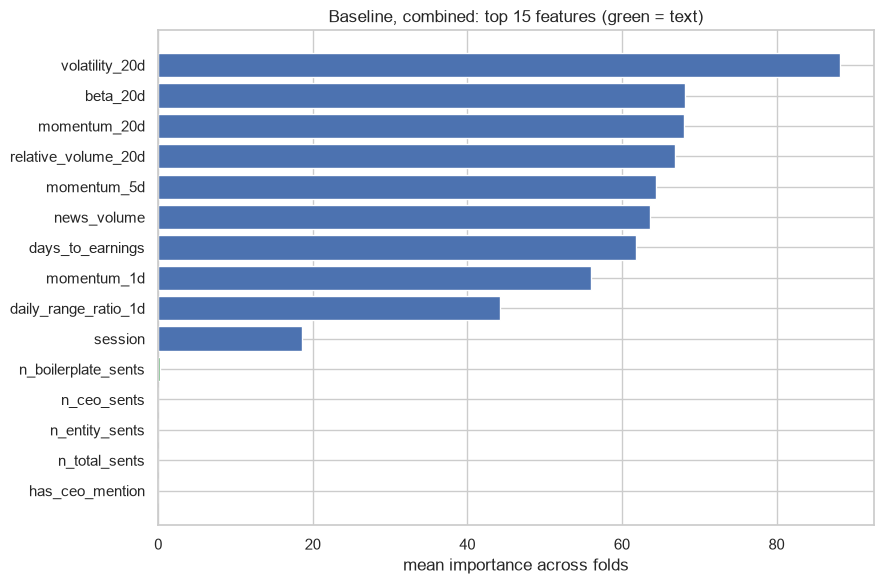

In [5]:
importance = feature_importance(runs["combined"], MODEL_FEATURES)
importance["layer"] = np.where(importance["feature"].isin(TEXT_FEATURES), "text", "market")

print(importance.head(15).round(2).to_string(index=False))

top10 = importance.head(10)
total = importance["importance_mean"].sum()
first_text = importance.reset_index(drop=True)
first_text_rank = int(first_text.index[first_text["layer"] == "text"].min()) + 1

print(f"\ntext features in the top 10 : {top10.loc[top10['layer'] == 'text', 'feature'].tolist()}")
print(f"top 5 share of importance   : {importance['importance_mean'].head(5).sum() / total:.1%}")
print(f"text share of importance    : "
      f"{importance.loc[importance['layer'] == 'text', 'importance_mean'].sum() / total:.1%}")
print(f"first text feature ranks    : {first_text_rank} of {len(importance)}")
print("\n3.2: top 10 all market, top 5 = 59.9%, first text feature ranked 11th")

fig, ax = plt.subplots(figsize=(9, 6))
top = importance.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"],
        color=np.where(top["layer"] == "text", "#55A868", "#4C72B0"))
ax.set_title("Baseline, combined: top 15 features (green = text)")
ax.set_xlabel("mean importance across folds")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.6-baseline-importance.png", dpi=120)
plt.show()


Worse than `3.2`, and unambiguous. The top ten features are all market state, as they were in `3.2`,
and the top five carry 59.3% of total importance, almost exactly `3.2`'s 59.9%. The first text
feature still ranks eleventh.

What is new is the last number: **text features carry 0.0% of total importance.** Not a small share,
none. Every one of the twenty is below rounding, and most are exactly zero, meaning the trees never
split on them at all. `3.2` at least had text features being used badly; here they are not used.

Twenty times the data has made this worse rather than better, which is the honest reading and a
consistent one. With 1,976 rows a shallow tree will split on a weak feature for want of anything
better. With 41,298 it has enough signal in the market features to never need to.


#### 1.5 The fingerprint ablation

`3.2` found that market features alone identify which fold a row came from with 99.6% accuracy, so a
model can recognise the period and answer whatever that period tended to do without reading the
article. `3.5` section 9 measured it again on this corpus: down to 1.9 times chance for the fold and
2.1 times for the ticker, much weaker but not gone, and it required that no accuracy number from this
notebook be reported without the ablation beside it.

This is that ablation. Identify the features carrying the fingerprint, drop them, and refit. If the
combined model's score survives, it was not leaning on them. If it collapses to the baseline, it was.


In [6]:
from sklearn.model_selection import cross_val_score

fold_id = np.full(len(df), -1)
for i, (_, test) in enumerate(row_grouped_splits(df["session_open"], n_splits=N_SPLITS)):
    fold_id[test] = i
scored = fold_id >= 0

numeric_market = [c for c in MARKET_FEATURES if c != "session"]
identifier = lgb.LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, verbosity=-1)
fold_acc = cross_val_score(
    identifier, df.loc[scored, numeric_market], fold_id[scored], cv=3, scoring="accuracy"
).mean()

identifier.fit(df.loc[scored, numeric_market], fold_id[scored])
fingerprint = (
    pd.Series(identifier.feature_importances_, index=numeric_market)
    .sort_values(ascending=False)
)
print(f"fold identified from market features alone: {fold_acc:.1%} against {1 / N_SPLITS:.1%} chance")
print("\nwhich features carry it:")
print(fingerprint.to_string())

FINGERPRINT_CLUSTER = fingerprint.head(4).index.tolist()
ablated = [c for c in MODEL_FEATURES if c not in FINGERPRINT_CLUSTER]
print(f"\ndropping: {FINGERPRINT_CLUSTER}")

runs["combined ablated"] = evaluate(model_factory, df, ablated, label_col=LABEL, n_splits=N_SPLITS)

comparison = []
for name in ["combined", "combined ablated", "text"]:
    agg = runs[name].aggregate.loc["mean"]
    comparison.append(
        {
            "features": name,
            "n features": len(MODEL_FEATURES) if name == "combined" else (
                len(ablated) if name == "combined ablated" else len(TEXT_FEATURES)
            ),
            "accuracy": agg["accuracy"],
            "baseline": agg["majority_baseline_accuracy"],
            "edge": agg["accuracy"] - agg["majority_baseline_accuracy"],
            "auc": agg["auc"],
            "mcnemar p": agg["mcnemar_p_value"],
        }
    )
print()
print(pd.DataFrame(comparison).round(4).to_string(index=False))


fold identified from market features alone: 38.7% against 20.0% chance

which features carry it:
days_to_earnings        2582
volatility_20d          2339
beta_20d                2241
news_volume             2155
momentum_20d            1878
momentum_5d             1185
relative_volume_20d     1010
momentum_1d              820
daily_range_ratio_1d     790

dropping: ['days_to_earnings', 'volatility_20d', 'beta_20d', 'news_volume']



        features  n features  accuracy  baseline    edge    auc  mcnemar p
        combined          30    0.5300    0.4898  0.0402 0.5449     0.2015
combined ablated          26    0.4787    0.4898 -0.0111 0.4934     0.6610
            text          20    0.4875    0.4898 -0.0023 0.5045     0.4963


### 2. Session-level aggregation (`3.4`'s config 2)

Section 1 found the article-level model has nothing to work with: text features carry zero
importance, and the market features only help by identifying the period. `3.4` hit the same wall and
its most promising answer was to stop modelling articles and start modelling sessions.

The argument is in `3.5` section 13. `abnormal_return_1d` is one number for a whole market session,
and a ticker-session carries a median of 41 articles and up to 218. Every one of them gets that same
number as its label, so a single article's sentiment is being asked to explain a move that dozens of
others also contributed to, or cancelled out. Nothing in the article-level table distinguishes the
one bearish article among forty bullish ones from one of forty equally bearish ones. Aggregating to
the session makes that distinction expressible: the session's mean sentiment, its spread, how many
articles it drew, how many sources.

`3.4` ran this and got the clearest structural result in the whole iteration. The fingerprint
collapsed from 99.6% to 22.2%, essentially chance, and sentiment finally earned real weight, second
in importance with a 35.3% top-five share against roughly 60% everywhere else. It still could not
reach significance, because aggregating 1,976 articles left 71 sessions and folds of 10 to 13 rows.

Pooled, the same aggregation leaves 924 ticker-sessions. That is the objection removed, which is why
this config goes first.


#### 2.1 Building the session table

One row per `(session_open, ticker)`. The recipe is `3.4`'s, with the grouping key changed.

`3.4` grouped by `abnormal_return_1d`, using the return value itself as a proxy for the session. On
the pooled table that happens to give the same 924 groups, but it works by luck rather than by
construction: nothing stops two tickers posting an identical return to full float precision, and
`session_open` now exists and says what it means.

**Counts sum, scores average, and market features are taken rather than averaged.** That last one is
`3.4`'s decision and it is the right one. Market features are cut at the article's calendar day, and
a session spans a median of two calendar days, so a session holds two versions of `momentum_1d`: one
ending at Thursday's close for Friday-afternoon articles, one ending at Friday's close for Monday
pre-market ones. At the Monday open, Friday's close is known. Averaging blends the current value with
a stale one; taking the latest article's snapshot keeps the freshest information legitimately
available at the moment being predicted.


In [7]:
def signed_max_abs(values: pd.Series) -> float:
    """The single loudest score in the group, keeping its sign."""
    values = values.dropna()
    if values.empty:
        return np.nan
    return values.iloc[values.abs().to_numpy().argmax()]


GROUP_KEYS = ["session_open", "ticker"]
MARKET_SNAPSHOT = [c for c in MARKET_FEATURES if c != "session"]

grouped = df.groupby(GROUP_KEYS, observed=True)

# The freshest market state in the session, not the average of a stale one and a current one.
latest_idx = grouped["timestamp_utc"].idxmax()
snapshot = df.loc[latest_idx, GROUP_KEYS + MARKET_SNAPSHOT].set_index(GROUP_KEYS)

sessions = grouped.agg(
    label_direction=("label_direction", "first"),
    abnormal_return_1d=("abnormal_return_1d", "first"),
    timestamp_utc=("timestamp_utc", "max"),
    n_articles=("article_id", "size"),
    n_sources=("source", "nunique"),
    n_total_sents=("n_total_sents", "sum"),
    n_entity_sents=("n_entity_sents", "sum"),
    n_ceo_sents=("n_ceo_sents", "sum"),
    n_boilerplate_sents=("n_boilerplate_sents", "sum"),
    article_length=("article_length", "sum"),
    entity_share=("entity_share", "mean"),
    has_ceo_mention=("has_ceo_mention", "mean"),
    fus_sentiment_mean=("fus_conf_graft_floor_mean", "mean"),
    fus_sentiment_std=("fus_conf_graft_floor_mean", "std"),
    fus_sentiment_loudest=("fus_conf_graft_floor_mean", signed_max_abs),
    fus_median=("fus_conf_graft_floor_median", "mean"),
    fus_lead=("fus_conf_graft_floor_lead", "mean"),
    fus_top3_pos=("fus_conf_graft_floor_top3_pos", "mean"),
    fus_top3_neg=("fus_conf_graft_floor_top3_neg", "mean"),
    fus_spread=("fus_conf_graft_floor_spread", "mean"),
    fus_ceo_mean=("fus_ceo_mean", "mean"),
    fus_headline=("fus_headline", "mean"),
    fus_maxmag=("fus_maxmag", "mean"),
    fus_trusted_mean=("fus_trusted_mean", "mean"),
    fus_scorer_gap=("fus_scorer_gap", "mean"),
    fus_headline_gap=("fus_headline_gap", "mean"),
    fus_lead_gap=("fus_lead_gap", "mean"),
)

# What mix of sessions the articles were published into, which the article-level
# table carried as a categorical and a session-level row cannot.
mix = (
    df.groupby(GROUP_KEYS + ["session"], observed=True)
    .size()
    .unstack("session", fill_value=0)
)
mix = mix.div(mix.sum(axis=1), axis=0)
mix.columns = [f"published_{c}_share" for c in mix.columns]
SESSION_MIX_FEATURES = list(mix.columns)

sessions = sessions.join(snapshot).join(mix).reset_index()
# Sorted by timestamp_utc, and by ticker to break ties, for two reasons.
#
# evaluate() sorts its input by timestamp_utc internally and returns fold indices
# against that order, so any frame indexed with fold.test_idx afterwards has to be
# in the same order. Sorting by session_open instead puts 657 of these 924 rows in
# a different position, because a session's timestamp is its last article's and
# sessions overlap in publication time.
#
# timestamp_utc alone is not unique here: 125 rows share one with another row,
# because an article covering two companies is the last article for both of their
# ticker-sessions. A stable sort leaves those ties in whatever order they arrived,
# so without a tie-break the fold each lands in depends on the incoming row order.
sessions = sessions.sort_values(["timestamp_utc", "ticker"]).reset_index(drop=True)
assert sessions["timestamp_utc"].is_monotonic_increasing
assert not sessions.duplicated(["timestamp_utc", "ticker"]).any()

# fus_sentiment_std is undefined for a single-article session; 0.0 is the honest
# reading, since a population of one has no disagreement in it.
sessions["fus_sentiment_std"] = sessions["fus_sentiment_std"].fillna(0.0)

print("session table:", sessions.shape)
print(sessions[["session_open", "ticker", "n_articles", "label_direction", "fus_sentiment_mean"]].head())


session table: (924, 41)
               session_open ticker  n_articles  label_direction  \
0 2025-09-02 13:30:00+00:00   AAPL          13               -1   
1 2025-09-02 13:30:00+00:00   TSLA          23               -1   
2 2025-09-02 13:30:00+00:00   AMZN          24               -1   
3 2025-09-02 13:30:00+00:00   NVDA          27               -1   
4 2025-09-03 13:30:00+00:00   AMZN          23               -1   

   fus_sentiment_mean  
0            0.057615  
1           -0.069181  
2            0.065619  
3            0.089829  
4            0.063232  


#### 2.2 Sanity pass

Row count, label balance, how much each row is aggregating over, and whether anything came out NaN.


In [8]:
print(f"rows                     : {len(sessions):,}   (from {len(df):,} articles)")
print(f"unique (session, ticker) : {sessions.duplicated(GROUP_KEYS).sum() == 0}")
print(f"sessions                 : {sessions['session_open'].nunique()}")
print(f"tickers                  : {sessions['ticker'].nunique()}")
print(f"span                     : {sessions['session_open'].min().date()} to {sessions['session_open'].max().date()}")

balance = sessions["label_direction"].value_counts(normalize=True)
print(f"\nlabel balance            : {(balance.get(1, 0)):.1%} up / {(balance.get(-1, 0)):.1%} down")
print(f"majority class           : {balance.max():.1%}")
print(f"article-level was        : 51.3%")

print("\narticles per session-row:")
print(sessions["n_articles"].describe().round(1).to_string())

missing = sessions.isna().mean()
missing = missing[missing > 0]
print("\ncolumns with NaN:")
print((missing * 100).round(2).to_string() if len(missing) else "  none")

print("\nsession-mix shares sum to 1 per row:",
      bool(np.allclose(sessions[SESSION_MIX_FEATURES].sum(axis=1), 1.0)))


rows                     : 924   (from 41,298 articles)
unique (session, ticker) : True
sessions                 : 231
tickers                  : 4
span                     : 2025-09-02 to 2026-08-03

label balance            : 48.9% up / 51.1% down
majority class           : 51.1%
article-level was        : 51.3%

articles per session-row:
count    924.0
mean      44.7
std       26.0
min        1.0
25%       27.0
50%       41.0
75%       57.0
max      218.0

columns with NaN:
fus_ceo_mean    4.11

session-mix shares sum to 1 per row: True


924 rows from 41,298 articles, one per ticker-session, and the aggregation is doing real work: a row
averages over 45 articles, median 41, up to 218. The label balance barely moves, 51.1% against the
article level's 51.3%, so the baseline a model has to beat is the same honest one.

`fus_ceo_mean` is NaN on 4.1% of rows, sessions where no article mentioned the CEO at all. That is
the population being empty rather than corruption, and LightGBM routes NaN itself, so it is left
alone for the reason `3.0` section 3 gave: 0.0 is a real score and filling with it would be a claim
that nothing was said, rather than that nothing was measured.


#### 2.3 The model at this scale

`min_child_samples=30` was chosen in `3.2` when a fold held a few hundred rows, and section 1 ran it
unchanged on folds of about 6,900. Aggregating takes the table to 924 rows and folds to roughly 150,
so a leaf needing 30 samples is now asking for a fifth of a fold. `3.4` faced the same problem and
dropped it to 5.

Every other parameter stays where it is, so the comparison against section 1 is still a comparison of
the data rather than of the model. This one has to move or the model cannot grow a tree at all, which
is a different kind of dishonesty.


In [9]:
def session_model_factory():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=100,
        num_leaves=7,
        learning_rate=0.05,
        min_child_samples=5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )


SESSION_TEXT_FEATURES = [
    "n_articles",
    "n_sources",
    "n_total_sents",
    "n_entity_sents",
    "n_ceo_sents",
    "n_boilerplate_sents",
    "article_length",
    "entity_share",
    "has_ceo_mention",
    "fus_sentiment_mean",
    "fus_sentiment_std",
    "fus_sentiment_loudest",
    "fus_median",
    "fus_lead",
    "fus_top3_pos",
    "fus_top3_neg",
    "fus_spread",
    "fus_ceo_mean",
    "fus_headline",
    "fus_maxmag",
    "fus_trusted_mean",
    "fus_scorer_gap",
    "fus_headline_gap",
    "fus_lead_gap",
]

SESSION_MARKET_FEATURES = MARKET_SNAPSHOT + SESSION_MIX_FEATURES
SESSION_MODEL_FEATURES = SESSION_TEXT_FEATURES + SESSION_MARKET_FEATURES

assert len(SESSION_MODEL_FEATURES) == len(set(SESSION_MODEL_FEATURES))
assert set(SESSION_MODEL_FEATURES + [LABEL]).issubset(sessions.columns)

print(f"SESSION_TEXT_FEATURES  : {len(SESSION_TEXT_FEATURES)}")
print(f"SESSION_MARKET_FEATURES: {len(SESSION_MARKET_FEATURES)}")
print(f"min_child_samples      : 5 (was 30), on folds of about {len(sessions) // (N_SPLITS + 1)}")


SESSION_TEXT_FEATURES  : 24
SESSION_MARKET_FEATURES: 12
min_child_samples      : 5 (was 30), on folds of about 154


#### 2.4 Through the harness

Same three feature sets, same splitter. Folds group on `session_open` exactly as before; at this
level a group is a session across all four tickers, so a fold holds whole sessions rather than whole
ticker-sessions.


In [10]:
session_runs = {}
for name, features in [
    ("market", SESSION_MARKET_FEATURES),
    ("text", SESSION_TEXT_FEATURES),
    ("combined", SESSION_MODEL_FEATURES),
]:
    session_runs[name] = evaluate(
        session_model_factory, sessions, features, label_col=LABEL, n_splits=N_SPLITS
    )

summary = []
for name, result in session_runs.items():
    agg = result.aggregate.loc["mean"]
    summary.append(
        {
            "features": name,
            "accuracy": agg["accuracy"],
            "weighted accuracy": weighted_aggregate(result).iloc[0]["accuracy"],
            "baseline": agg["majority_baseline_accuracy"],
            "edge": agg["accuracy"] - agg["majority_baseline_accuracy"],
            "auc": agg["auc"],
            "log loss": agg["log_loss"],
            "mcnemar p": agg["mcnemar_p_value"],
            "folds beating baseline": int(sum(f.metrics["beats_baseline"] for f in result.folds)),
            "folds significant": int(
                sum(f.metrics["significantly_beats_baseline"] for f in result.folds)
            ),
        }
    )
print(pd.DataFrame(summary).round(4).to_string(index=False))

print("\ncombined, fold by fold:")
cols = ["fold", "n_train", "n_test", "accuracy", "majority_baseline_accuracy", "auc", "mcnemar_p_value"]
print(session_runs["combined"].metrics_df[cols].round(4).to_string(index=False))

print("\narticle level (section 1.2): market 0.5441, text 0.4875, combined 0.5300")
print("3.4 (71 sessions, one ticker): best AUC 0.644 with the ensemble, nothing significant")


features  accuracy  weighted accuracy  baseline   edge    auc  log loss  mcnemar p  folds beating baseline  folds significant
  market    0.5094             0.5091     0.486 0.0234 0.5210    0.7485     0.3968                       4                  0
    text    0.4964             0.4961     0.486 0.0104 0.5117    0.7714     0.4665                       3                  0
combined    0.5135             0.5130     0.486 0.0275 0.5459    0.7620     0.4124                       3                  1

combined, fold by fold:
 fold  n_train  n_test  accuracy  majority_baseline_accuracy    auc  mcnemar_p_value
    1      156     152    0.5592                      0.5066 0.6000           0.2226
    2      308     156    0.4167                      0.4295 0.4722           0.6673
    3      464     152    0.5592                      0.4474 0.5762           0.0166
    4      616     156    0.5192                      0.4872 0.5038           0.3482
    5      772     152    0.5132              

**Combined beats market-only, but barely, and everything here is smaller than section 1.** 51.35%
against 50.94%, a gap of 0.4 points where at article level market-only won by 1.4. The direction is
reversed, which is what this config predicted, and the margin is far too small to lean on.

Text-only crosses to the right side of its baseline for the first time in the notebook, +1.0 points
against the article level's -0.2. That is the clearest thing in this section: aggregating makes the
text features stop being actively unhelpful.

**It is not significant, and it is less significant than section 1.** p = 0.412 with one fold of
five, against four of five at article level. Folds here hold about 152 rows rather than 6,900, so the
same edge carries forty-five times less evidence behind it. Section 1.2's warning cuts both ways and
this is the other side of it.

**A caution about how stable any of this is.** These numbers moved by 1.7 points depending on how the
session table happened to be sorted, before the sort was made deterministic. `evaluate()` orders its
input by `timestamp_utc`, which is not unique here: 125 of 924 rows share one with another row,
because an article covering two companies is the last article for both of their ticker-sessions. A
stable sort leaves those ties in whatever order they arrived, so which fold each landed in depended
on the incoming row order. Sorting by `(timestamp_utc, ticker)` settles it.

The fix matters less than what it revealed. A 1.7-point swing from an arbitrary ordering choice, on a
table whose edge over baseline is 2.8 points, means the folds here are small enough that the result
is not stable to decisions that should not matter at all. Every number in this section should be read
with that width around it.


#### 2.5 Is it learning, or defaulting?

Same check as section 1.3, on far fewer rows. With folds of roughly 150 a model can score well by
accident, so what it predicted matters more here than what it scored.


In [11]:
rows = []
for fold in session_runs["combined"].folds:
    train_pos = (sessions[LABEL].iloc[fold.train_idx] > 0).mean()
    test_pos = (sessions[LABEL].iloc[fold.test_idx] > 0).mean()
    pred_pos = (pd.Series(fold.y_pred) > 0).mean()
    rows.append(
        {
            "fold": fold.fold,
            "n_test": len(fold.test_idx),
            "train positive": f"{train_pos:.1%}",
            "test positive": f"{test_pos:.1%}",
            "predicted positive": f"{pred_pos:.1%}",
            "accuracy": round(fold.metrics["accuracy"], 4),
            "baseline": round(fold.metrics["majority_baseline_accuracy"], 4),
            "matches train lean": (pred_pos > 0.5) == (train_pos > 0.5),
            "matches test lean": (pred_pos > 0.5) == (test_pos > 0.5),
        }
    )
session_prediction = pd.DataFrame(rows)
print(session_prediction.to_string(index=False))
print(f"\nmatches training's lean : {int(session_prediction['matches train lean'].sum())}/{len(session_prediction)}")
print(f"matches the test lean   : {int(session_prediction['matches test lean'].sum())}/{len(session_prediction)}")
print("\narticle level (section 1.3): 3/5 and 1/5")


 fold  n_test train positive test positive predicted positive  accuracy  baseline  matches train lean  matches test lean
    1     152          51.9%         50.7%              44.7%    0.5592    0.5066               False              False
    2     156          51.3%         42.9%              69.2%    0.4167    0.4295                True              False
    3     152          48.5%         55.3%              37.5%    0.5592    0.4474                True              False
    4     156          50.2%         48.7%              32.7%    0.5192    0.4872               False               True
    5     152          49.9%         44.1%              55.9%    0.5132    0.5592               False              False

matches training's lean : 2/5
matches the test lean   : 1/5

article level (section 1.3): 3/5 and 1/5


Predictions swing harder than at article level, 32.7% to 69.2% positive against 36.9% to 63.0%, which
is what a 152-row fold does to a model whose parameters were chosen for thousands. Two folds of five
follow training's lean and one follows the test fold's, both about what chance would give.

So the model is not defaulting to the majority class, and it is not reliably calling the direction of
a fold either. What changed against section 1 is not the quality of the predictions but which
features are producing them, which is section 2.6.


#### 2.6 Feature importance

`3.4`'s headline structural result was here: sentiment second in importance, top-five share 35.3%
against roughly 60% at article level, and text features finally being split on.


                     feature  importance_mean  importance_std  layer
       fus_sentiment_loudest             32.4            5.71   text
         relative_volume_20d             32.2            2.86 market
published_market-hours_share             31.6            3.14 market
              n_entity_sents             27.4            5.50   text
            fus_headline_gap             24.6            3.93   text
                fus_lead_gap             24.4            6.28   text
                fus_ceo_mean             24.0            3.41   text
  published_pre-market_share             22.0            5.90 market
        daily_range_ratio_1d             21.8            4.45 market
                 news_volume             20.4            4.63 market
                momentum_20d             20.4            3.67 market
                   n_sources             19.6            6.25   text
           fus_sentiment_std             19.6            4.36   text
         n_boilerplate_sents      

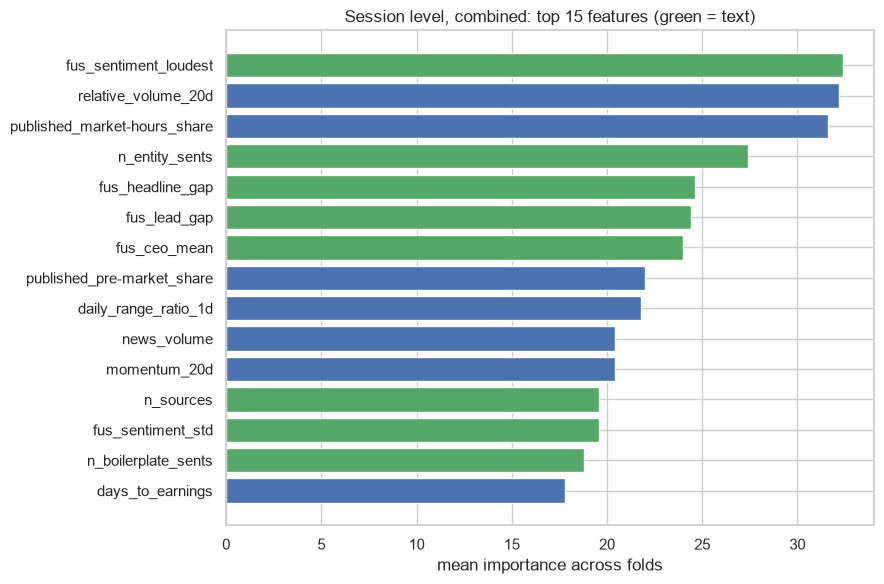

In [12]:
session_importance = feature_importance(session_runs["combined"], SESSION_MODEL_FEATURES)
session_importance["layer"] = np.where(
    session_importance["feature"].isin(SESSION_TEXT_FEATURES), "text", "market"
)

print(session_importance.head(15).round(2).to_string(index=False))

total = session_importance["importance_mean"].sum()
top10 = session_importance.head(10)
ranked = session_importance.reset_index(drop=True)
first_text_rank = int(ranked.index[ranked["layer"] == "text"].min()) + 1

print(f"\ntext features in the top 10: {top10.loc[top10['layer'] == 'text', 'feature'].tolist()}")
print(f"top 5 share of importance  : {session_importance['importance_mean'].head(5).sum() / total:.1%}")
print(f"text share of importance   : "
      f"{session_importance.loc[session_importance['layer'] == 'text', 'importance_mean'].sum() / total:.1%}")
print(f"first text feature ranks   : {first_text_rank} of {len(session_importance)}")
print("\narticle level (section 1.4): top 5 = 59.3%, text share 0.0%, first text ranked 11th")
print("3.4 (session level, one ticker): sentiment 2nd, top 5 = 35.3%")

fig, ax = plt.subplots(figsize=(9, 6))
top = session_importance.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"],
        color=np.where(top["layer"] == "text", "#55A868", "#4C72B0"))
ax.set_title("Session level, combined: top 15 features (green = text)")
ax.set_xlabel("mean importance across folds")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.6-session-importance.png", dpi=120)
plt.show()


**This is the result of the notebook so far.** Text features carry **60.1%** of total importance,
against 0.0% at article level. `fus_sentiment_loudest`, the single loudest article in the session,
ranks **first of thirty-six**. Five of the top ten are text.

The top-five share falls to 24.7% from 59.3%, so importance is spread across many features rather
than concentrated in a handful of market ones. That is what a model looks like when it has found
something to use rather than one shortcut to lean on.

This replicates `3.4`'s structural finding and goes past it. `3.4` got sentiment to second place with
a 35.3% top-five share on one ticker and 71 sessions; here the loudest-article feature is first, and
the text layer as a whole is carrying most of the model.

Worth being precise about what this does and does not show. It says the model is using the text
features. It does not say the text features are working, because the accuracy is still 53% with
p = 0.412. A model can distribute importance across features that are collectively no better than a
coin flip, and importance is not evidence of skill. What it does mean is that the article-level
finding, that text is unusable, was an artifact of the unit rather than a fact about the text.


#### 2.7 The fingerprint at session level

`3.4` found aggregating collapsed fold identification from 99.6% to 22.2%, barely above the 20%
chance floor. That was the strongest argument for this config: it removes the shortcut rather than
asking the model not to take it.

Same measurement here, plus the ticker version, since pooling adds that second route.


In [13]:
session_fold_id = np.full(len(sessions), -1)
for i, (_, test) in enumerate(row_grouped_splits(sessions["session_open"], n_splits=N_SPLITS)):
    session_fold_id[test] = i
scored = session_fold_id >= 0

identifier = lgb.LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, verbosity=-1)
session_fold_acc = cross_val_score(
    identifier, sessions.loc[scored, SESSION_MARKET_FEATURES], session_fold_id[scored],
    cv=3, scoring="accuracy",
).mean()
session_ticker_acc = cross_val_score(
    lgb.LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1),
    sessions[SESSION_MARKET_FEATURES], sessions["ticker"], cv=3, scoring="accuracy",
).mean()

print(pd.DataFrame([
    {"target": "which fold a row is from", "rows": int(scored.sum()),
     "accuracy": f"{session_fold_acc:.1%}", "chance": f"{1 / N_SPLITS:.1%}",
     "lift": f"{session_fold_acc / (1 / N_SPLITS):.1f}x"},
    {"target": "which ticker a row is", "rows": len(sessions),
     "accuracy": f"{session_ticker_acc:.1%}", "chance": "25.0%",
     "lift": f"{session_ticker_acc / 0.25:.1f}x"},
]).to_string(index=False))

print("\narticle level (3.5 section 9): fold 1.9x, ticker 2.1x")
print("3.4 (session level, one ticker): fold 1.1x")

identifier.fit(sessions.loc[scored, SESSION_MARKET_FEATURES], session_fold_id[scored])
session_fingerprint = pd.Series(
    identifier.feature_importances_, index=SESSION_MARKET_FEATURES
).sort_values(ascending=False)
SESSION_FINGERPRINT_CLUSTER = session_fingerprint.head(4).index.tolist()
print(f"\ncarried by: {SESSION_FINGERPRINT_CLUSTER}")

ablated = [c for c in SESSION_MODEL_FEATURES if c not in SESSION_FINGERPRINT_CLUSTER]
session_runs["combined ablated"] = evaluate(
    session_model_factory, sessions, ablated, label_col=LABEL, n_splits=N_SPLITS
)

comparison = []
for name in ["combined", "combined ablated", "text"]:
    agg = session_runs[name].aggregate.loc["mean"]
    comparison.append(
        {
            "features": name,
            "accuracy": agg["accuracy"],
            "baseline": agg["majority_baseline_accuracy"],
            "edge": agg["accuracy"] - agg["majority_baseline_accuracy"],
            "auc": agg["auc"],
            "mcnemar p": agg["mcnemar_p_value"],
        }
    )
print()
print(pd.DataFrame(comparison).round(4).to_string(index=False))
print("\narticle level (section 1.5): combined 0.5300 -> ablated 0.4787, edge +0.040 -> -0.011")


                  target  rows accuracy chance lift
which fold a row is from   768    41.5%  20.0% 2.1x
   which ticker a row is   924    56.3%  25.0% 2.3x

article level (3.5 section 9): fold 1.9x, ticker 2.1x
3.4 (session level, one ticker): fold 1.1x

carried by: ['volatility_20d', 'beta_20d', 'days_to_earnings', 'momentum_20d']



        features  accuracy  baseline   edge    auc  mcnemar p
        combined    0.5135     0.486 0.0275 0.5459     0.4124
combined ablated    0.5253     0.486 0.0394 0.5482     0.3184
            text    0.4964     0.486 0.0104 0.5117     0.4665

article level (section 1.5): combined 0.5300 -> ablated 0.4787, edge +0.040 -> -0.011


### 3. Relative sentiment (`3.4`'s config 1)

`3.4`'s reasoning: a raw sentiment score says how positive an article is in absolute terms, but the
market has already priced in the general mood. What might matter is whether this article is more
positive than the others around it, not whether it is positive at all. So subtract the surrounding
mean and model the difference.

It was the closest `3.4` came to a result. Text-only improved on every metric and its p-value moved
from 0.291 to 0.110, nearer significance than anything else in that notebook. It never fixed the
underlying problem though: the combined model still gave every top-ten importance slot to market
features, exactly as in `3.2`.

This is an article-level transform, so it runs on `df` rather than on the session table.


#### 3.1 Which features generalise to the transform

Not all twenty text features. `3.4` split them three ways and only one group is eligible.

Counts and structural features are out of scope: "this article had three more sentences than average"
is a different quantity from a sentence count, and not obviously a better one. Features that are
already a difference are deferred, since subtracting a mean from a gap gives a gap between gaps,
which is hard to argue for and harder to read.

That leaves the nine signed scores.


In [14]:
STRUCTURAL_COLS = [
    "n_total_sents",
    "n_entity_sents",
    "n_ceo_sents",
    "n_boilerplate_sents",
    "entity_share",
    "article_length",
    "has_ceo_mention",
]
ALREADY_DIFFERENCE_COLS = [
    "fus_conf_graft_floor_spread",
    "fus_scorer_gap",
    "fus_headline_gap",
    "fus_lead_gap",
]
RELATIVE_CANDIDATES = [
    c for c in TEXT_FEATURES if c not in STRUCTURAL_COLS + ALREADY_DIFFERENCE_COLS
]

assert set(STRUCTURAL_COLS + ALREADY_DIFFERENCE_COLS + RELATIVE_CANDIDATES) == set(TEXT_FEATURES)

print(f"structural or a count, out of scope: {len(STRUCTURAL_COLS)}")
print(f"already a difference, deferred     : {len(ALREADY_DIFFERENCE_COLS)}")
print(f"eligible for the transform         : {len(RELATIVE_CANDIDATES)}")
print(RELATIVE_CANDIDATES)


structural or a count, out of scope: 7
already a difference, deferred     : 4
eligible for the transform         : 9
['fus_conf_graft_floor_mean', 'fus_conf_graft_floor_median', 'fus_conf_graft_floor_lead', 'fus_conf_graft_floor_top3_pos', 'fus_conf_graft_floor_top3_neg', 'fus_ceo_mean', 'fus_headline', 'fus_maxmag', 'fus_trusted_mean']


#### 3.2 Building them, two ways

`3.4` subtracted each calendar day's mean, on a corpus with one ticker. Pooled, "the surrounding
mean" is ambiguous and the two readings are genuinely different questions.

**Within ticker.** Subtract the mean over the same ticker's articles in the same session. Asks: is
this article more positive than the rest of today's coverage *of this company*. This is `3.4`'s
transform ported, with the session replacing the calendar day for the reason `3.5` section 8 gave.

**Cross-sectional.** Subtract the mean over every article in the same session, all four tickers.
Asks: is this article more positive than the market mood right now. This one could not exist before
pooling, and it is closer to what an abnormal return is: a move measured against the market rather
than in absolute terms. The label is already ticker-minus-SPY, so a feature measured the same way has
a certain symmetry to it.

Neither is obviously right, so both get built and both get run.

A note on what the transform does to solo rows. An article that is the only one for its ticker in its
session becomes exactly 0 under the within-ticker transform, since it is its own mean. That is not a
neutral sentiment reading, it is an absence of comparison, and it is worth knowing how many rows it
affects before reading anything into the feature.


In [15]:
SESSION_KEY = df["session_open"]

RELATIVE_MAP = {
    "fus_conf_graft_floor_mean": "rel_sentiment",
    "fus_conf_graft_floor_median": "rel_median",
    "fus_conf_graft_floor_lead": "rel_lead",
    "fus_conf_graft_floor_top3_pos": "rel_top3_pos",
    "fus_conf_graft_floor_top3_neg": "rel_top3_neg",
    "fus_ceo_mean": "rel_ceo_mean",
    "fus_headline": "rel_headline",
    "fus_maxmag": "rel_maxmag",
    "fus_trusted_mean": "rel_trusted_mean",
}
assert set(RELATIVE_MAP) == set(RELATIVE_CANDIDATES)

within_cols, cross_cols = [], []
for raw, stem in RELATIVE_MAP.items():
    within = f"{stem}_within"
    cross = f"{stem}_cross"
    df[within] = df[raw] - df.groupby(["session_open", "ticker"], observed=True)[raw].transform("mean")
    df[cross] = df[raw] - df.groupby("session_open", observed=True)[raw].transform("mean")
    within_cols.append(within)
    cross_cols.append(cross)

per_ticker_session = df.groupby(["session_open", "ticker"], observed=True)["article_id"].transform("size")
per_session = df.groupby("session_open", observed=True)["article_id"].transform("size")

print(f"rows alone in their ticker-session: {int((per_ticker_session == 1).sum()):,} "
      f"({(per_ticker_session == 1).mean():.2%})")
print(f"rows alone in their session       : {int((per_session == 1).sum()):,} "
      f"({(per_session == 1).mean():.2%})")

print("\nwhat the transform does to the spread:")
spread = pd.DataFrame(
    [
        {
            "feature": raw,
            "raw std": df[raw].std(),
            "within std": df[f"{stem}_within"].std(),
            "cross std": df[f"{stem}_cross"].std(),
            "within / raw": df[f"{stem}_within"].std() / df[raw].std(),
            "cross / raw": df[f"{stem}_cross"].std() / df[raw].std(),
        }
        for raw, stem in RELATIVE_MAP.items()
    ]
).round(3)
print(spread.to_string(index=False))


rows alone in their ticker-session: 3 (0.01%)
rows alone in their session       : 0 (0.00%)

what the transform does to the spread:
                      feature  raw std  within std  cross std  within / raw  cross / raw
    fus_conf_graft_floor_mean    0.150       0.143      0.148         0.954        0.987
  fus_conf_graft_floor_median    0.400       0.385      0.395         0.962        0.988
    fus_conf_graft_floor_lead    0.357       0.346      0.353         0.968        0.990
fus_conf_graft_floor_top3_pos    0.435       0.423      0.431         0.973        0.990
fus_conf_graft_floor_top3_neg    0.450       0.430      0.445         0.955        0.989
                 fus_ceo_mean    0.357       0.329      0.349         0.921        0.979
                 fus_headline    0.434       0.424      0.430         0.976        0.990
                   fus_maxmag    0.656       0.628      0.649         0.957        0.989
             fus_trusted_mean    0.149       0.142      0.147      

The solo-row worry is nothing: 3 rows of 41,298 are alone in their ticker-session and none are alone
in their session. Pooling four tickers over a dense corpus leaves almost nothing without a comparison
group.

The spread column is the finding, and it arrives before any model is fitted. Subtracting the mean
barely changes the distribution. The within-ticker transform leaves 92% to 98% of each feature's
standard deviation intact, and the cross-sectional one leaves 98% to 99%.

That is a statement about where sentiment varies. If subtracting the session mean removes only about
5% of a feature's spread, then roughly 90% of the variation was already *within* a session rather
than between sessions, and the "surrounding mood" this config exists to remove is close to constant.
There is very little for the transform to take away, so there is very little it can do.

Cross-sectional removes even less than within-ticker, which follows: averaging across four companies
smooths the session mean further and leaves a flatter thing to subtract.


#### 3.3 Through the harness

Three feature sets against section 1's baseline: the raw scores replaced by the within-ticker
version, then by the cross-sectional version. Structural and already-difference features stay raw in
both, since neither was transformed.

Text-only is the run that matters here. `3.4`'s finding was specifically that text-only improved
under the transform while combined did not, and section 1.4 found text carries no importance at all
in the combined model, so a change there would be invisible.


In [16]:
UNTRANSFORMED_TEXT = STRUCTURAL_COLS + ALREADY_DIFFERENCE_COLS
TEXT_WITHIN = UNTRANSFORMED_TEXT + within_cols
TEXT_CROSS = UNTRANSFORMED_TEXT + cross_cols

relative_runs = {}
for name, text_set in [
    ("raw", TEXT_FEATURES),
    ("within ticker", TEXT_WITHIN),
    ("cross sectional", TEXT_CROSS),
]:
    relative_runs[f"text, {name}"] = evaluate(
        model_factory, df, text_set, label_col=LABEL, n_splits=N_SPLITS
    )
    relative_runs[f"combined, {name}"] = evaluate(
        model_factory, df, text_set + MARKET_FEATURES, label_col=LABEL, n_splits=N_SPLITS
    )

summary = []
for name, result in relative_runs.items():
    agg = result.aggregate.loc["mean"]
    summary.append(
        {
            "run": name,
            "accuracy": agg["accuracy"],
            "baseline": agg["majority_baseline_accuracy"],
            "edge": agg["accuracy"] - agg["majority_baseline_accuracy"],
            "auc": agg["auc"],
            "log loss": agg["log_loss"],
            "mcnemar p": agg["mcnemar_p_value"],
            "folds significant": int(
                sum(f.metrics["significantly_beats_baseline"] for f in result.folds)
            ),
        }
    )
print(pd.DataFrame(summary).round(4).to_string(index=False))
print("\n3.4 (one ticker, day-relative): text-only p 0.291 -> 0.110, combined unchanged")


                      run  accuracy  baseline    edge    auc  log loss  mcnemar p  folds significant
                text, raw    0.4875    0.4898 -0.0023 0.5045    0.7018     0.4963                  2
            combined, raw    0.5300    0.4898  0.0402 0.5449    0.7250     0.2015                  4
      text, within ticker    0.4916    0.4898  0.0018 0.5052    0.7026     0.4442                  2
  combined, within ticker    0.5289    0.4898  0.0392 0.5435    0.7253     0.2308                  3
    text, cross sectional    0.4858    0.4898 -0.0040 0.4958    0.7056     0.6414                  1
combined, cross sectional    0.5271    0.4898  0.0373 0.5446    0.7260     0.2015                  4

3.4 (one ticker, day-relative): text-only p 0.291 -> 0.110, combined unchanged


Almost nothing moves, and what moves is the sign rather than the size.

Within-ticker nudges text-only from 48.75% to 49.16%, which takes its edge over baseline from -0.2
points to +0.2 and its p-value from 0.496 to 0.444. That is the same direction `3.4` reported and a
far smaller version of it: `3.4` moved text-only from 0.291 to 0.110, close enough to significance to
be worth chasing. 0.444 is not.

Cross-sectional is worse than raw on every measure, 48.58% accuracy, AUC 0.496 which is below chance,
p 0.641. The question it asks, whether an article is more positive than the market mood, is a
reasonable one and the answer here is no.

The combined models are unchanged to slightly worse: 53.00% raw, 52.89% within, 52.71% cross. Which
is what section 1.4 predicted would happen. Transforming features that carry 0.0% of the model's
importance cannot change the model, whatever the transform does to them.


#### 3.4 Is it learning, or defaulting?

On whichever transform did better, the same check as sections 1.3 and 2.5.


In [17]:
best_relative = max(
    ("text, within ticker", "text, cross sectional"),
    key=lambda k: relative_runs[k].aggregate.loc["mean"]["accuracy"],
)
print(f"better text-only transform: {best_relative}\n")

rows = []
for fold in relative_runs[best_relative].folds:
    train_pos = (df[LABEL].iloc[fold.train_idx] > 0).mean()
    test_pos = (df[LABEL].iloc[fold.test_idx] > 0).mean()
    pred_pos = (pd.Series(fold.y_pred) > 0).mean()
    rows.append(
        {
            "fold": fold.fold,
            "train positive": f"{train_pos:.1%}",
            "test positive": f"{test_pos:.1%}",
            "predicted positive": f"{pred_pos:.1%}",
            "accuracy": round(fold.metrics["accuracy"], 4),
            "baseline": round(fold.metrics["majority_baseline_accuracy"], 4),
            "matches train lean": (pred_pos > 0.5) == (train_pos > 0.5),
            "matches test lean": (pred_pos > 0.5) == (test_pos > 0.5),
        }
    )
relative_prediction = pd.DataFrame(rows)
print(relative_prediction.to_string(index=False))
print(f"\nmatches training's lean : {int(relative_prediction['matches train lean'].sum())}/5")
print(f"matches the test lean   : {int(relative_prediction['matches test lean'].sum())}/5")
print("\nsection 1.3 (raw, combined): 3/5 and 1/5")


better text-only transform: text, within ticker

 fold train positive test positive predicted positive  accuracy  baseline  matches train lean  matches test lean
    1          57.4%         44.0%              91.9%    0.4462    0.4405                True              False
    2          50.7%         52.6%              56.8%    0.5135    0.5259                True               True
    3          51.3%         51.8%              75.9%    0.5223    0.5178                True               True
    4          51.4%         41.6%              75.1%    0.4590    0.4163                True              False
    5          49.4%         45.1%              37.4%    0.5169    0.5485                True               True

matches training's lean : 5/5
matches the test lean   : 3/5

section 1.3 (raw, combined): 3/5 and 1/5


Worth reading against section 1.3 rather than as a result on its own. Predicted positive rates now
run 37.4% to 91.9%, and the model follows training's own lean in **all five folds** where the raw
combined model followed it in three.

That is a model leaning harder on the prior, not one that has found something. It matches the test
fold's direction 3 times of 5 against 1 of 5, which sounds better and is not: predicting the training
majority every time will match the test fold whenever the two happen to agree, which on this corpus
is roughly half the time.

Fold 1 is the clearest case. Training leaned 57.4% positive, the model predicted positive on 91.9% of
rows, and the fold actually came in at 44.0% positive. It scored 44.6% against a 44.1% baseline.


#### 3.5 Feature importance

Whether the transform changes which features the combined model reaches for. `3.4`'s complaint was
that it did not: every top-ten slot stayed with market features. Section 1.4 found the same thing more
starkly, with text at 0.0% of importance.

No fingerprint subsection here. The transform touches only text features, so the market features and
therefore the fingerprint are identical to section 1.5's by construction. Re-measuring it would be
re-running the same computation on the same columns.


In [18]:
best_combined = best_relative.replace("text,", "combined,")
best_features = (
    TEXT_WITHIN if "within" in best_combined else TEXT_CROSS
) + MARKET_FEATURES

relative_importance = feature_importance(relative_runs[best_combined], best_features)
relative_importance["layer"] = np.where(
    relative_importance["feature"].isin(MARKET_FEATURES), "market", "text"
)

print(f"{best_combined}\n")
print(relative_importance.head(15).round(2).to_string(index=False))

total = relative_importance["importance_mean"].sum()
top10 = relative_importance.head(10)
ranked = relative_importance.reset_index(drop=True)
first_text_rank = int(ranked.index[ranked["layer"] == "text"].min()) + 1

print(f"\ntext features in the top 10: {top10.loc[top10['layer'] == 'text', 'feature'].tolist()}")
print(f"top 5 share of importance  : {relative_importance['importance_mean'].head(5).sum() / total:.1%}")
print(f"text share of importance   : "
      f"{relative_importance.loc[relative_importance['layer'] == 'text', 'importance_mean'].sum() / total:.1%}")
print(f"first text feature ranks   : {first_text_rank} of {len(relative_importance)}")
print("\nsection 1.4 (raw): top 5 = 59.3%, text share 0.0%, first text ranked 11th")
print("section 2.6 (session level): top 5 = 24.7%, text share 60.1%, first text ranked 1st")


combined, within ticker

             feature  importance_mean  importance_std  layer
      volatility_20d             88.8           21.49 market
            beta_20d             68.8           13.39 market
        momentum_20d             67.6            6.41 market
 relative_volume_20d             66.2           14.68 market
         momentum_5d             64.0            9.57 market
         news_volume             63.0           13.86 market
    days_to_earnings             57.8            3.82 market
         momentum_1d             57.6           13.03 market
daily_range_ratio_1d             44.0            6.13 market
             session             18.8           13.54 market
   rel_maxmag_within              2.6            1.85   text
 rel_top3_neg_within              0.4            0.80   text
     rel_lead_within              0.4            0.80   text
       n_total_sents              0.0            0.00   text
   rel_median_within              0.0            0.00   text

### 4. Market/text ensemble (`3.4`'s config 3)

The other two configs change what the model sees. This one changes how it is fitted. Instead of one
model on market and text features together, fit two, one on each, and average their predicted
probabilities.

The argument for it is section 1.4. In a single tree ensemble the market features win every split,
and the text features are never reached, so they contribute nothing regardless of whether they carry
information. Fitting text on its own forces it to produce a prediction, and blending gives that
prediction a guaranteed share of the final answer rather than leaving it to compete for splits it
always loses.

`3.4` found it helped calibration on config 1, log loss and Brier, without helping accuracy, and
helped everything on config 2 where it produced that notebook's best AUC of 0.644, still not
significant.

Tested on two bases here: the article-level baseline from section 1, and the session-level table from
section 2. Config 1 is not carried forward, for the reason section 3.5 gave.


#### 4.1 Building it

`3.4`'s blend, unchanged: average the two models' positive-class probabilities with equal weight, then
threshold at 0.5. The fold boundaries have to match row for row between the two runs or the blend is
meaningless, so that is asserted rather than assumed.

Equal weighting is a choice, not a result. Tuning the weight on the same folds the models are scored
on would be fitting to the test set, so it stays at 0.5 and section 4.2 looks at what a weight sweep
would have found without using it to pick.


In [19]:
from stock_predictor.market.evaluate import _score


def ensemble_metrics(result_market, result_text, data, label_col, weight=0.5):
    """Blend two runs' probabilities fold by fold and score the result."""
    for fold_market, fold_text in zip(result_market.folds, result_text.folds):
        assert (fold_market.train_idx == fold_text.train_idx).all(), "train folds differ"
        assert (fold_market.test_idx == fold_text.test_idx).all(), "test folds differ"

    rows = []
    for fold_market, fold_text in zip(result_market.folds, result_text.folds):
        pos_label = max(fold_market.model.classes_)
        neg_label = min(fold_market.model.classes_)
        market_col = list(fold_market.model.classes_).index(pos_label)
        text_col = list(fold_text.model.classes_).index(pos_label)

        blended = (
            weight * fold_market.y_proba[:, market_col]
            + (1 - weight) * fold_text.y_proba[:, text_col]
        )
        y_pred = np.where(blended >= 0.5, pos_label, neg_label)

        rows.append(
            _score(
                data[label_col].iloc[fold_market.train_idx],
                data[label_col].iloc[fold_market.test_idx],
                y_pred,
                blended,
                pos_label,
            )
        )

    metrics = pd.DataFrame(rows)
    metrics.insert(0, "fold", range(1, len(rows) + 1))
    return metrics


ensemble_article = ensemble_metrics(runs["market"], runs["text"], df, LABEL)
ensemble_session = ensemble_metrics(
    session_runs["market"], session_runs["text"], sessions, LABEL
)
print("fold boundaries align on both bases: confirmed")

print("\narticle level, per fold:")
cols = ["fold", "n_test", "accuracy", "majority_baseline_accuracy", "auc", "mcnemar_p_value"]
print(ensemble_article[cols].round(4).to_string(index=False))

print("\nsession level, per fold:")
print(ensemble_session[cols].round(4).to_string(index=False))


fold boundaries align on both bases: confirmed

article level, per fold:


 fold  n_test  accuracy  majority_baseline_accuracy    auc  mcnemar_p_value
    1    6947    0.4688                      0.4405 0.5028           0.0000
    2    6827    0.5874                      0.5259 0.6047           0.0000
    3    6864    0.5012                      0.5178 0.4992           0.9623
    4    7091    0.5606                      0.4163 0.5773           0.0000
    5    6727    0.5595                      0.5485 0.5816           0.1093

session level, per fold:
 fold  n_test  accuracy  majority_baseline_accuracy    auc  mcnemar_p_value
    1     152    0.5132                      0.5066 0.5616           0.5000
    2     156    0.4359                      0.4295 0.4540           0.5000
    3     152    0.5395                      0.4474 0.5401           0.0728
    4     156    0.5192                      0.4872 0.5069           0.3439
    5     152    0.5461                      0.5592 0.5468           0.6282


The fold p-values at article level repeat section 1.2's pattern: three folds at 0.0000, one at 0.96,
one at 0.11, on folds of nearly 7,000. At session level nothing is below 0.22, on folds of 152. Same
models, same blend, forty-five times the evidence per fold.


#### 4.2 Against the single combined model

The comparison that matters is not ensemble against baseline, it is ensemble against the combined
model on the same base. Both see exactly the same features; the only difference is whether text gets
its own model or has to win splits against market features.


In [20]:
def as_row(name, metrics):
    return {
        "run": name,
        "accuracy": metrics["accuracy"].mean(),
        "baseline": metrics["majority_baseline_accuracy"].mean(),
        "edge": metrics["accuracy"].mean() - metrics["majority_baseline_accuracy"].mean(),
        "auc": metrics["auc"].mean(),
        "log loss": metrics["log_loss"].mean(),
        "brier": metrics["brier_score"].mean(),
        "mcnemar p": metrics["mcnemar_p_value"].mean(),
        "folds significant": int(metrics["significantly_beats_baseline"].sum()),
    }


comparison = pd.DataFrame(
    [
        as_row("article: combined", runs["combined"].metrics_df),
        as_row("article: ensemble", ensemble_article),
        as_row("session: combined", session_runs["combined"].metrics_df),
        as_row("session: ensemble", ensemble_session),
    ]
)
print(comparison.round(4).to_string(index=False))
print("\n3.4 (config 2, one ticker): ensemble gave that notebook's best AUC, 0.644, not significant")

# What a weight sweep would have found. Reported, not used to choose: picking a
# weight on the same folds the model is scored on is fitting to the test set.
sweep = []
for weight in [0.0, 0.25, 0.5, 0.75, 1.0]:
    article = ensemble_metrics(runs["market"], runs["text"], df, LABEL, weight=weight)
    session = ensemble_metrics(
        session_runs["market"], session_runs["text"], sessions, LABEL, weight=weight
    )
    sweep.append(
        {
            "market weight": weight,
            "article accuracy": article["accuracy"].mean(),
            "article auc": article["auc"].mean(),
            "session accuracy": session["accuracy"].mean(),
            "session auc": session["auc"].mean(),
        }
    )
print("\nweight sweep (0.0 = text only, 1.0 = market only):")
print(pd.DataFrame(sweep).round(4).to_string(index=False))


              run  accuracy  baseline   edge    auc  log loss  brier  mcnemar p  folds significant
article: combined    0.5300    0.4898 0.0402 0.5449    0.7250 0.2630     0.2015                  4
article: ensemble    0.5355    0.4898 0.0457 0.5531    0.7003 0.2533     0.2143                  3
session: combined    0.5135    0.4860 0.0275 0.5459    0.7620 0.2754     0.4124                  1
session: ensemble    0.5108    0.4860 0.0248 0.5219    0.7265 0.2646     0.4090                  0

3.4 (config 2, one ticker): ensemble gave that notebook's best AUC, 0.644, not significant



weight sweep (0.0 = text only, 1.0 = market only):
 market weight  article accuracy  article auc  session accuracy  session auc
          0.00            0.4874       0.5048            0.4938       0.5070
          0.25            0.5256       0.5440            0.5057       0.5125
          0.50            0.5355       0.5531            0.5108       0.5219
          0.75            0.5376       0.5547            0.5198       0.5238
          1.00            0.5395       0.5554            0.5094       0.5177


### 5. Every run, side by side

Sections 1 to 4 each compared a config against its own reference. This puts all of them in one table,
then asks which of the differences are real rather than which are largest.

Two things to hold on to while reading it. The article-level and session-level runs are scored on
different populations, 41,298 rows against 924, so their baselines differ and their accuracies are
not directly comparable as numbers. And section 2.4 measured a 1.7-point swing in the session-level
result from nothing more than a change of sort order, so differences smaller than that are not
differences.


#### 5.1 The table


In [21]:
def summarise(name, level, metrics):
    """One row from either an EvalResult's metrics_df or an ensemble metrics frame."""
    return {
        "level": level,
        "run": name,
        "n rows": int(metrics["n_test"].sum()),
        "accuracy": metrics["accuracy"].mean(),
        "baseline": metrics["majority_baseline_accuracy"].mean(),
        "edge": metrics["accuracy"].mean() - metrics["majority_baseline_accuracy"].mean(),
        "auc": metrics["auc"].mean(),
        "log loss": metrics["log_loss"].mean(),
        "brier": metrics["brier_score"].mean(),
        "folds beating baseline": int(metrics["beats_baseline"].sum()),
        "folds significant": int(metrics["significantly_beats_baseline"].sum()),
    }


all_runs = [
    summarise("market only", "article", runs["market"].metrics_df),
    summarise("text only", "article", runs["text"].metrics_df),
    summarise("combined (baseline)", "article", runs["combined"].metrics_df),
    summarise("combined, fingerprint ablated", "article", runs["combined ablated"].metrics_df),
    summarise("text, relative within ticker", "article", relative_runs["text, within ticker"].metrics_df),
    summarise("text, relative cross sectional", "article", relative_runs["text, cross sectional"].metrics_df),
    summarise("combined, relative within ticker", "article", relative_runs["combined, within ticker"].metrics_df),
    summarise("combined, relative cross sectional", "article", relative_runs["combined, cross sectional"].metrics_df),
    summarise("ensemble (market + text)", "article", ensemble_article),
    summarise("market only", "session", session_runs["market"].metrics_df),
    summarise("text only", "session", session_runs["text"].metrics_df),
    summarise("combined", "session", session_runs["combined"].metrics_df),
    summarise("combined, fingerprint ablated", "session", session_runs["combined ablated"].metrics_df),
    summarise("ensemble (market + text)", "session", ensemble_session),
]

comparison = pd.DataFrame(all_runs).sort_values(["level", "edge"], ascending=[True, False])
print(comparison.round(4).to_string(index=False))


  level                                run  n rows  accuracy  baseline    edge    auc  log loss  brier  folds beating baseline  folds significant
article                        market only   34456    0.5441    0.4898  0.0543 0.5595    0.7265 0.2630                       4                  3
article           ensemble (market + text)   34456    0.5355    0.4898  0.0457 0.5531    0.7003 0.2533                       4                  3
article                combined (baseline)   34456    0.5300    0.4898  0.0402 0.5449    0.7250 0.2630                       4                  4
article   combined, relative within ticker   34456    0.5289    0.4898  0.0392 0.5435    0.7253 0.2631                       4                  3
article combined, relative cross sectional   34456    0.5271    0.4898  0.0373 0.5446    0.7260 0.2632                       4                  4
article       text, relative within ticker   34456    0.4916    0.4898  0.0018 0.5052    0.7026 0.2546                      

**At article level the best run is the one with no text in it.** Market-only tops the table at +5.4
points of edge, and every run that adds text features sits below it. The ordering is market-only,
then the ensemble, then combined, then the three relative-sentiment variants, then the text-only runs
below their baseline, then the ablated model at the bottom.

**At session level the ordering inverts and the numbers shrink.** The fingerprint-ablated model leads
at +3.9 points, combined follows, market-only is fourth of five. Every session-level run beats its
baseline on more folds than it loses, and not one of them is significant on a single fold except
combined's one.

The two levels disagree about whether text helps, which is the whole finding of the notebook so far,
and neither of them produces a number that clears `3.2`'s 53 to 57% bar in a way that survives
section 5.2.


#### 5.2 Which of those differences are real

Ranking by accuracy invites reading the top row as the winner. The table above has fourteen rows and
its accuracies span about five points, so something has to be top whether or not anything works.

Two checks. First, every run against its own baseline, which the table already reports and which
nothing clears convincingly. Second, and more to the point, the configs against each other: a paired
McNemar between two models on the same rows, which asks whether one is right more often than the
other where they disagree, rather than comparing two means that were each measured with noise.


In [22]:
from stock_predictor.market.evaluate import _mcnemar_p_value


def paired_mcnemar(result_a, result_b, data, label_col):
    """Is A right more often than B, on the rows where they disagree?

    Pooled across folds, since the folds are identical between the two runs and a
    per-fold test on 152 rows has almost no power.
    """
    y_true, pred_a, pred_b = [], [], []
    for fold_a, fold_b in zip(result_a.folds, result_b.folds):
        assert (fold_a.test_idx == fold_b.test_idx).all(), "folds differ, cannot pair"
        y_true.append(data[label_col].iloc[fold_a.test_idx].to_numpy())
        pred_a.append(np.asarray(fold_a.y_pred))
        pred_b.append(np.asarray(fold_b.y_pred))

    y_true = np.concatenate(y_true)
    pred_a = np.concatenate(pred_a)
    pred_b = np.concatenate(pred_b)
    disagree = int((pred_a != pred_b).sum())
    return {
        "rows": len(y_true),
        "disagreements": disagree,
        "a accuracy": float((pred_a == y_true).mean()),
        "b accuracy": float((pred_b == y_true).mean()),
        "p (a better than b)": _mcnemar_p_value(y_true, pred_a, pred_b),
        "p (b better than a)": _mcnemar_p_value(y_true, pred_b, pred_a),
    }


pairs = [
    ("article: combined vs market only", runs["combined"], runs["market"], df),
    ("article: combined vs ablated", runs["combined"], runs["combined ablated"], df),
    ("article: relative within vs raw", relative_runs["combined, within ticker"], runs["combined"], df),
    ("article: relative cross vs raw", relative_runs["combined, cross sectional"], runs["combined"], df),
    ("session: combined vs market only", session_runs["combined"], session_runs["market"], sessions),
    ("session: combined vs text only", session_runs["combined"], session_runs["text"], sessions),
    ("session: ablated vs combined", session_runs["combined ablated"], session_runs["combined"], sessions),
]

rows = []
for name, run_a, run_b, data in pairs:
    row = {"comparison": name}
    row.update(paired_mcnemar(run_a, run_b, data, LABEL))
    rows.append(row)
print(pd.DataFrame(rows).round(4).to_string(index=False))


                      comparison  rows  disagreements  a accuracy  b accuracy  p (a better than b)  p (b better than a)
article: combined vs market only 34456           3029      0.5279      0.5394               1.0000               0.0000
    article: combined vs ablated 34456          10608      0.5279      0.4795               0.0000               1.0000
 article: relative within vs raw 34456           1050      0.5268      0.5279               0.8732               0.1400
  article: relative cross vs raw 34456            387      0.5254      0.5279               1.0000               0.0000
session: combined vs market only   768            251      0.5078      0.5091               0.5502               0.5000
  session: combined vs text only   768            217      0.5078      0.4935               0.2487               0.7923
    session: ablated vs combined   768            145      0.5195      0.5078               0.2533               0.7968


This is the section that settles it, and it settles it against the text layer.

**Adding text to market features makes the article-level model significantly worse.** Combined
against market-only: they disagree on 3,029 rows, and market-only is right more often on those, at
p < 0.0001. Not "market-only is a bit ahead", but a difference large enough and consistent enough to
be real. The twenty text features are actively costing accuracy.

**The fingerprint result holds up under the same test.** Combined against its ablated version:
10,608 disagreements, combined significantly better at p < 0.0001. Section 1.5 said the edge was the
four calendar-carrying features; this confirms it on the rows where the two models actually differ.

**Cross-sectional relative sentiment significantly hurts.** Against raw, on 387 disagreements, raw is
better at p < 0.0001. Within-ticker is indistinguishable from raw, p 0.87 and 0.14 in the two
directions, which is the honest version of section 3.3's "marginal improvement": there is no
improvement, there is noise that happened to land the right way.

**At session level nothing is distinguishable from anything.** All six p-values sit between 0.25 and
0.80. The models barely disagree in the first place, 145 to 251 rows out of 768, and on the rows
where they do neither is reliably better. Section 2's structural findings, text carrying 60% of
importance and the ablation not hurting, are real statements about how the model is built. They are
not statements about whether it works, and this is where that distinction gets enforced.


#### 5.3 Does any of it hold per ticker?

Everything above is pooled across four companies. `3.5` section 7 chose to pool and kept per-ticker
models as the comparison, so this is that comparison: split the pooled predictions back out by ticker
and see whether a result is spread across the four or carried by one.

A config that works on one company and not the others is not a finding about news, it is a finding
about that company, and the question this project asks is explicitly whether a model generalises
across firms.


In [23]:
def per_ticker(result, data, label_col):
    rows = []
    for fold in result.folds:
        block = data.iloc[fold.test_idx][[label_col, "ticker"]].copy()
        block["pred"] = np.asarray(fold.y_pred)
        rows.append(block)
    predictions = pd.concat(rows)
    predictions["correct"] = predictions["pred"] == predictions[label_col]

    out = predictions.groupby("ticker").agg(
        rows=("correct", "size"),
        accuracy=("correct", "mean"),
    )
    majority = predictions.groupby("ticker")[label_col].agg(
        lambda s: max((s > 0).mean(), (s <= 0).mean())
    )
    out["majority share"] = majority
    out["edge"] = out["accuracy"] - out["majority share"]
    return out.round(4)


print("article level, combined (section 1.2):")
print(per_ticker(runs["combined"], df, LABEL).to_string())

print("\nsession level, combined (section 2.4):")
print(per_ticker(session_runs["combined"], sessions, LABEL).to_string())

print("\nsession level, fingerprint ablated (section 2.7, the best edge in the notebook):")
print(per_ticker(session_runs["combined ablated"], sessions, LABEL).to_string())


article level, combined (section 1.2):
         rows  accuracy  majority share    edge
ticker                                         
AAPL     6332    0.4907          0.5055 -0.0148
AMZN     9124    0.5090          0.5362 -0.0272
NVDA    11617    0.5588          0.5205  0.0383
TSLA     7383    0.5343          0.5679 -0.0336

session level, combined (section 2.4):
        rows  accuracy  majority share    edge
ticker                                        
AAPL     192    0.5365          0.5052  0.0312
AMZN     192    0.4844          0.5104 -0.0260
NVDA     192    0.5156          0.5104  0.0052
TSLA     192    0.4948          0.5417 -0.0469

session level, fingerprint ablated (section 2.7, the best edge in the notebook):
        rows  accuracy  majority share    edge
ticker                                        
AAPL     192    0.5156          0.5052  0.0104
AMZN     192    0.4844          0.5104 -0.0260
NVDA     192    0.5625          0.5104  0.0521
TSLA     192    0.5156          0.

### 6. Summary

**The baseline does not work, and the reason is specific.** Section 1 ran `3.3`'s model on the pooled
table and got 53.0% accuracy against a 48.98% baseline, which is inside the band `3.2` called a real
result. Section 1.4 found text features carrying **0.0%** of total importance, not a small share but
none: most were never split on. Section 1.5 dropped the four market features that best identify which
fold a row is from, and accuracy fell to 47.87%, below the baseline. The 53% was the model
recognising roughly when a row was from and answering whatever that period tended to do.

**Config 2, session-level aggregation, is the only config that changes the model's structure.**
Aggregating 41,298 articles to 924 ticker-sessions moved text from 0.0% of importance to **60.1%**,
put `fus_sentiment_loudest` first of thirty-six features, and made text-only beat its baseline for the
first time in the notebook. The fingerprint ablation stopped hurting: removing those four features
raised accuracy rather than destroying it. What it did not do is produce a result. p = 0.412, one
significant fold of five, and the numbers move by 1.7 points when nothing changes but the sort order
of the input table.

**Config 1, relative sentiment, does not work, and section 3.2 said why before a model ran.**
Subtracting the session mean leaves 92% to 98% of each feature's spread intact, so roughly 90% of
sentiment variation was already within a session and there is almost nothing for the transform to
remove. Within-ticker is indistinguishable from raw under a paired test; cross-sectional is
significantly worse. `3.4` saw a larger movement from the same idea on a smaller, noisier corpus,
which is the expected direction for something that was mostly removing noise rather than finding
signal.

**Config 3, the ensemble, adds nothing on its own but improves calibration everywhere.** At article
level the weight sweep climbs monotonically to market-only, so the apparent gain is a slower route to
discarding text entirely. At session level it is marginally worse than one combined model, with the
one qualification that its weight curve has a genuine interior optimum, the only place in the notebook
one appears. Every ensemble beat its single-model counterpart on log loss and Brier, which matters for
a demo that reports confidence.

**Section 5 is where it stops being ambiguous.** A paired McNemar between models, rather than each
model against a baseline, found that adding text features to the article-level model makes it
significantly worse at p < 0.0001, on 3,029 rows where the two disagree. At session level nothing is
distinguishable from anything: all six comparisons sit between p = 0.25 and 0.80, and the models
barely disagree in the first place.

**And one ticker was carrying most of the pooled number.** Splitting the article-level predictions
back out by company, only NVDA clears its own majority share, at +3.8 points, while AAPL, AMZN and
TSLA sit below theirs. `3.5` chose to pool for good reasons that all still hold, and pooling also
averaged four companies into a number that was not describing all four.

**Two things were found that are not about the models.** The evaluation harness sorts its input by
`timestamp_utc`, which is not unique on the session table, so fold membership depended on incoming
row order until section 2.1 made the sort deterministic. And `evaluate()` returns fold indices against
its own internal sort, so any frame indexed with them afterwards has to be in the same order, which is
easy to get wrong and silent when you do.


### 7. Decision

**This iteration is a null result, and it is a properly defended one.**

`3.4` could not separate its three configs from noise and blamed the corpus. That explanation is now
spent. The corpus samples the year evenly, the folds are even and grouped on the unit the label is
built from, `momentum_1d` is verified leak-free on every ticker, and the table is twenty times larger
across four companies instead of one. All three configs were re-run against it and none of them
works at article level: text features carry 0.0% of importance, and adding them makes the model
significantly worse (section 5.2). This is a valid, presentable finding: article-level financial news sentiment does not
predict next-session abnormal returns on these tickers, and the accuracy that looked like it did was
the model reading the calendar.

**Iteration five is `3.7`: heavy hyperparameter tuning on config 2, and only config 2.**

Session-level aggregation is the one config that changed anything structural. Text carries 60.1% of
importance against 0.0% at article level, `fus_sentiment_loudest` ranks first of thirty-six features,
the fingerprint ablation stops hurting and starts helping, and the ensemble's weight sweep is the only
place in this notebook with a genuine interior optimum rather than a monotonic slide to market-only.
Nothing else this notebook tried earned a second look; config 1 was shown to be removing noise rather
than finding signal (section 3.2) and the article-level ensemble just discards text more slowly.

`3.7` runs a real tuning search over both of config 2's forms side by side, the single combined model
and the market/text ensemble (including the blend weight, fixed at an untested 0.5 here), and reports
whichever comes out ahead. Both were built with hyperparameters chosen in `3.2` for folds of a few
hundred rows and never revisited at session scale (folds of roughly 150), so there is real room for
tuning to move the number before concluding anything about the ceiling. `n_splits` is in scope too:
this is a new corpus at a new row count, and `3.3`'s finding that more folds hurt was measured on the
old 1,976-row, TSLA-only table, not this one, so it gets re-tested rather than assumed to still hold.

**The search has to be disciplined, because 768 scored rows makes it easy to find something that looks
good and isn't.**

- Lock the last fifth of sessions chronologically before any tuning starts, and look at it once, at
  the end. `3.1` built no held-out block on the reasoning that fold metrics are enough once every
  decision is locked in; tuning is precisely when decisions stop being locked in, so a holdout is what
  that reasoning now requires.
- Tune inside the training folds only. Choosing hyperparameters on the folds this notebook reports
  would be fitting the test set and would invalidate every comparison `3.7` makes against it.
- Write the grid and the stopping rule down before running them, so the size of the search is on the
  record and a reader can judge how inflated the best result is.
- Report the whole tuning curve, not the winner. With enough configurations tried, the maximum is
  inflated by construction regardless of whether anything real is there.

**Stated in advance: this is expected to fail.** Tuning typically buys one or two AUC points on a real
signal, and roughly five are needed here. Call it a 15% chance of clearing a locked test set. Worth
running anyway: "we tried to make it work, here is exactly how hard, and here is what it gave" is a
stronger position than never trying, and the answer is reportable either way.

Not recommended: tuning the article-level model, since section 5.2 already showed text makes it
significantly worse there, so tuning it would at best recover the market-only fingerprint result, not
a text-driven one.